# Credit Risk Modeling in Python

https://www.datacamp.com/courses/credit-risk-modeling-in-python

## Block 2 - Logistic Regression for Defaults

Probabilities of default as an outcome from machine learning, either with:
- Logistic regression
- Decision tree

Entire data set is usually split into two parts
- Train: Learn from the data to generate predictions
- Test: Test learning on new unseen data

train_test_split() function already within sci-kit learn:
- X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=123)

### Logistic regression basics

Creating and training a logistic regression model with just one feature: **loan_int_rate**.

https://en.wikipedia.org/wiki/Logistic_regression

https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html

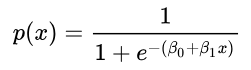

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("cr_loan_w2.csv")
df.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,21,9600,5,1000,11.14,0,0.10,2,0,0,...,0,0,1,0,0,0,0,0,1,0
1,25,9600,1,5500,12.87,1,0.57,3,1,0,...,0,0,0,1,0,0,0,0,1,0
2,23,65500,4,35000,15.23,1,0.53,2,0,0,...,0,0,0,1,0,0,0,0,1,0
3,24,54400,8,35000,14.27,1,0.55,4,0,0,...,0,0,0,1,0,0,0,0,0,1
4,21,9900,2,2500,7.14,1,0.25,2,0,0,...,1,1,0,0,0,0,0,0,1,0


Text(2, 13.759749342410645, '13.06')

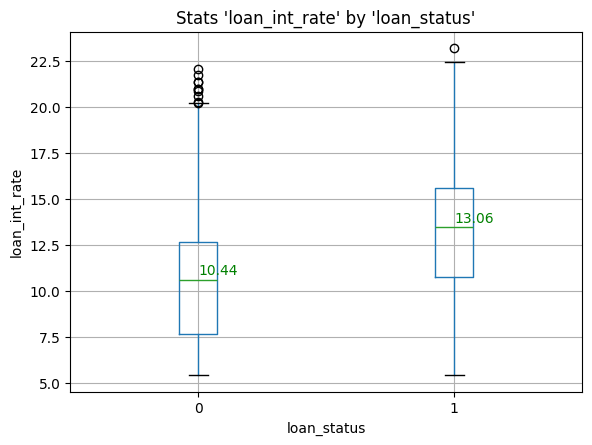

In [3]:
df.boxplot(column="loan_int_rate", by="loan_status")
plt.title("Stats 'loan_int_rate' by 'loan_status'")
plt.ylabel("loan_int_rate")
plt.suptitle("")
plt.text(1,df.groupby("loan_status").mean()["loan_int_rate"][0]+0.5,str(round(df.groupby("loan_status").mean()["loan_int_rate"][0],2)),color="g")
plt.text(2,df.groupby("loan_status").mean()["loan_int_rate"][1]+0.7,str(round(df.groupby("loan_status").mean()["loan_int_rate"][1],2)),color="g")

Figure above: On average, default loans (status: 1) are subject to larger interest rates.

Below: to start, without split train/test!

In [4]:
# Let's take 1 feature
X = df["loan_int_rate"].values.reshape(-1,1) # Reshape with 1 col

# Target variable
y = df["loan_status"]

# Call LogisticRegression model
model1 = LogisticRegression(solver="lbfgs")

# Fit model to raw data
model1.fit(X, y)

print(model1.get_params())
print(model1.intercept_)

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 100, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}
[-4.45784525]


In [5]:
# Let's take 2 features
X = df[["loan_int_rate", "person_emp_length"]]

# Target variable
y = df["loan_status"]

# Call LogisticRegression model
model2 = LogisticRegression(solver="lbfgs").fit(X, y)

print(model2.intercept_)

[-4.21644963]


### Split Train/Test

https://scikit-learn.org/1.5/modules/generated/sklearn.model_selection.train_test_split.html

Now let's split the dataset in train and test.

The training set is used to make predictions, while the test set is used for evaluation. Without evaluating the model, you have no way to tell how well it will perform on new loan data.

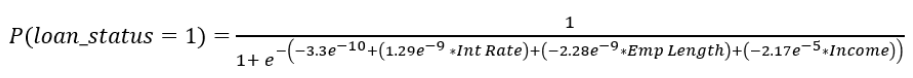

In [6]:
from sklearn.model_selection import train_test_split

# Let's take the features
X = df[["loan_int_rate", "loan_int_rate", "person_income"]]
y = df["loan_status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=610)

# Call model and fit using train set
model3 = LogisticRegression(solver="lbfgs").fit(X_train, y_train)

# Model intercept (b0)
print(model3.intercept_)

# Coefficient for our features (b1, b2, b3): ["loan_int_rate", "loan_int_rate", "person_income"]
print(model3.coef_)

[-3.34661442]
[[ 1.43845908e-01  1.43845908e-01 -2.26520520e-05]]


### One-hot encoding credit data

Prepare the **non-numeric columns** so they can be added to your LogisticRegression() model

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html

In [7]:
df = pd.read_csv("cr_loan2.csv")

# Drop rows with NaN values
df = df.dropna(axis=0)

df_num = df.select_dtypes(exclude=["object"]) # Exclude string columns
df_str = df.select_dtypes(include=["object"]) # Only string columns

# One-hot encoding string columns
one_hot = pd.get_dummies(df_str)

# Concat two dfs
df_new = pd.concat([df_num, one_hot], axis=1)

df_new.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,False,False,False,True,False,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,False,...,False,False,True,False,False,False,False,False,True,False
2,25,9600,1.0,5500,12.87,1,0.57,3,True,False,...,False,False,False,True,False,False,False,False,True,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,False,False,False,True,False,False,False,False,True,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,False,False,False,True,False,False,False,False,False,True


### Predicting probability of default

Data processing is complete and it's time to begin creating predictions for probability of default.

C:\Users\remon\AppData\Local\Temp\ipykernel_3860\506596442.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X_test.iloc[:,i], results, alpha=0.5, c=np.random.rand(3,))


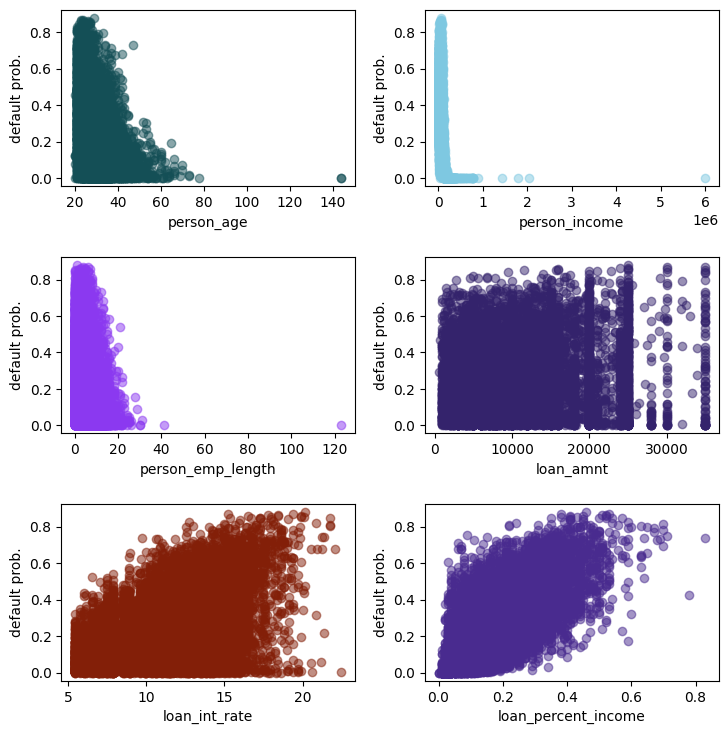

In [8]:
# Features, already with one-hot
X = df_new.drop("loan_status", axis=1)
# Target
y = df_new["loan_status"]

# Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.4, random_state=610)

# Model and Fit
model4 = LogisticRegression(solver="liblinear").fit(X_train, y_train)

# Prediction of probabilities 
prob = model4.predict_proba(X_test)
results = pd.DataFrame(prob[:,1], columns=["prob_default"])

# Let's scatter 'results' vs all features
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(7,7))
fig.tight_layout(pad=0, w_pad=2, h_pad=3)

i = 0
for row in axes:
    for ax in row:
        ax.scatter(X_test.iloc[:,i], results, alpha=0.5, c=np.random.rand(3,))
        ax.set_ylabel("default prob.")
        ax.set_xlabel(X_test.columns[i])
        i += 1

### Model Performance

**Accuracy** = % of correct predictions = .score()

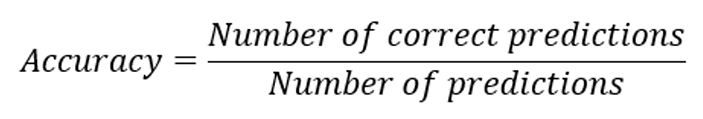

In [9]:
from sklearn.metrics import classification_report

# Create a dataframe for the probabilities of default
preds_df = pd.DataFrame(prob[:,1], columns = ['prob_default'])

# Reassign loan status based on the threshold
preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > 0.5 else 0)

target_names = ['Non-Default', 'Default']
print(classification_report(y_test, preds_df["loan_status"], target_names=target_names))

# precision = TP / (TP + FP)
# recall = TP / (TP + TN)

              precision    recall  f1-score   support

 Non-Default       0.84      0.96      0.90      8990
     Default       0.68      0.34      0.46      2466

    accuracy                           0.82     11456
   macro avg       0.76      0.65      0.68     11456
weighted avg       0.81      0.82      0.80     11456



### Visually scoring credit models (ROC chart)

The ROC curve is drawn by calculating the true positive rate (TPR) and false positive rate (FPR) at every possible threshold (in practice, at selected intervals), then graphing TPR over FPR.

- For a threshold t, any sample with a score ≥ t is classified as positive.
- Any sample with a score < t is classified as negative.

Accuracy Score = 82.44587988826815


Text(0, 0.5, 'TPR')

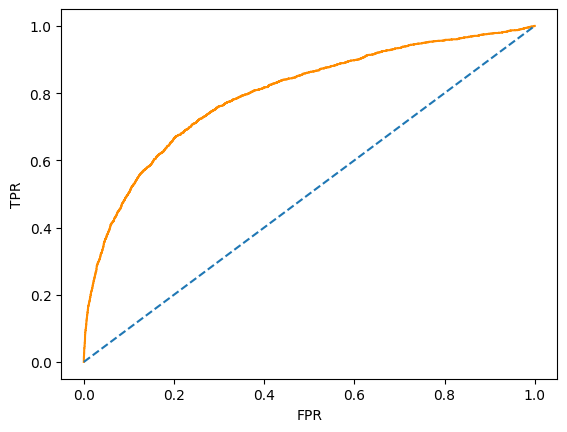

In [10]:
from sklearn.metrics import roc_curve

# Accuracy Score of our model
print("Accuracy Score = " + str(model4.score(X_test, y_test)*100))

# ROC curve
fallout, sensitivity, thresholds = roc_curve(y_test, preds_df["prob_default"])
plt.plot(fallout, sensitivity, color = 'darkorange')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")

### Thresholds and confusion matrices

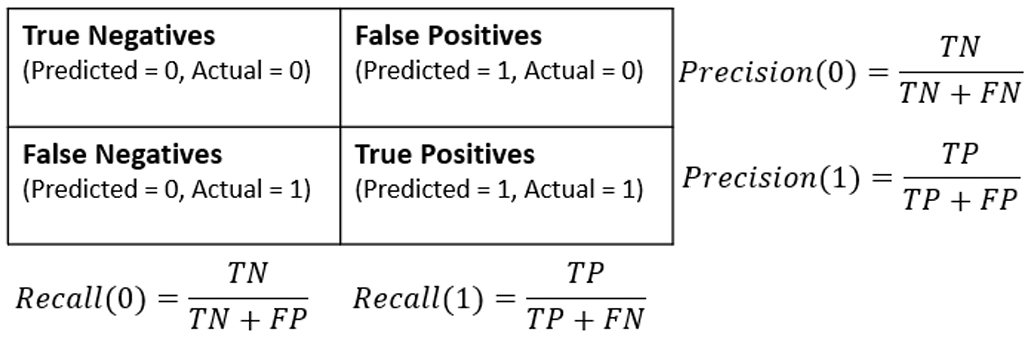

Difficult to maximize all of them because there is a trade-off.

Set different values for the threshold on probability of default, and use a confusion matrix to see how the changing values affect the model's performance.


In [11]:
from sklearn.metrics import confusion_matrix

print("Default Threshold = 0.5")

# Threshold x > 0.5 = default
preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > 0.5 else 0)
print(preds_df.head())

# Print the confusion matrix
cm = confusion_matrix(y_test,preds_df["loan_status"])
print(cm)

# Calculate "Default Recall Score" with Threshold 0.5
print("Default Recall Score = " + str(cm[1][1] / (cm[1][0]+cm[1][1])) + "\n")

print("Default Threshold = 0.4")

# Threshold x > 0.5 = default
preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > 0.4 else 0)
print(preds_df.head())

# Print the confusion matrix
cm = confusion_matrix(y_test,preds_df["loan_status"])
print(cm)

# Calculate "Default Recall Score" with Threshold 0.4
print(">> Default Recall Score = " + str(cm[1][1] / (cm[1][0]+cm[1][1])) + " <<") # larger!

Default Threshold = 0.5
   prob_default  loan_status
0      0.560258            1
1      0.023265            0
2      0.162237            0
3      0.404820            0
4      0.020456            0
[[8601  389]
 [1622  844]]
Default Recall Score = 0.3422546634225466

Default Threshold = 0.4
   prob_default  loan_status
0      0.560258            1
1      0.023265            0
2      0.162237            0
3      0.404820            1
4      0.020456            0
[[8054  936]
 [1195 1271]]
>> Default Recall Score = 0.5154095701540957 <<


### How thresholds affect performance

**DEFAULT RECALL = TP / (TP + FN)**

Setting the threshold to 0.4 shows promising results for model evaluation. Now you can assess the financial impact using the default recall which is selected from the classification reporting using the function precision_recall_fscore_support().

For this, you will estimate the amount of unexpected loss using the default recall **to find what proportion of defaults you did not catch with the new threshold**. This will be a dollar amount which tells you how much in losses you would have if all the unfound defaults were to default all at once.

In [12]:
from sklearn.metrics import precision_recall_fscore_support

# We use x > 0.4 as Threshold for Defaults
preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > 0.4 else 0)

# Number of Default Loans
number_default = preds_df["loan_status"].value_counts()[1]

# Default Recall
default_recall = precision_recall_fscore_support(y_test, preds_df["loan_status"])[1][1]

# Calculate Estimated Loss due to False Negative!
avg_loan_amount = X["loan_amnt"].mean()
print("Loss Estimate due to False Negative = $ " + str(avg_loan_amount * number_default * (1 - default_recall)))

Loss Estimate due to False Negative = $ 10327533.244176812


### Threshold selection

You know there is a **trade off** between metrics like default recall, non-default recall, and model accuracy. One easy way to approximate a good starting threshold value is to look at a plot of all three using matplotlib. With this graph, you can see how each of these metrics look as you change the threshold values and find the point at which the performance of all three is good enough to use for the credit data.

Text(0.5, 0, 'Probability Threshold')

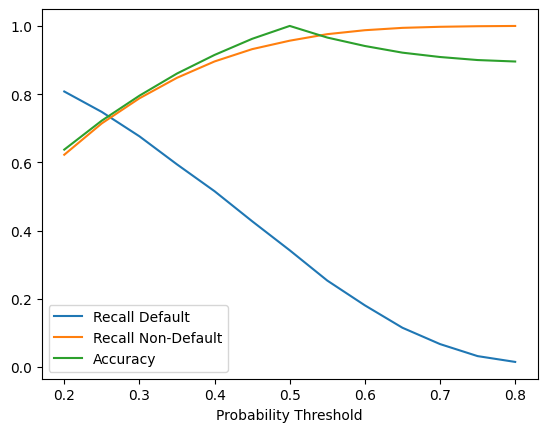

In [38]:
# List of Default Thresholds
thresholds = np.arange(0.2, 0.8, 0.05)

recall_default = []
recall_nondefault = []
accuracy = []
for t in thresholds:
    # Update Prediction wrt Threshold
    preds_df["loan_status"] = preds_df["prob_default"].apply(lambda x: 1 if x > t else 0)
    # Measures
    recall_default.append(precision_recall_fscore_support(y_test, preds_df["loan_status"])[1][1])
    recall_nondefault.append(precision_recall_fscore_support(y_test, preds_df["loan_status"])[1][0])
    accuracy.append(model4.score(X_test, preds_df["loan_status"]))

plt.plot(thresholds, recall_default, label="Recall Default")
plt.plot(thresholds, recall_nondefault, label="Recall Non-Default")
plt.plot(thresholds, accuracy, label="Accuracy")
plt.legend()
plt.xlabel("Probability Threshold")